In [2]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

## 1. Data Loading and Initial Exploration:
###  1. Load the dataset into a pandas DataFrame.
###  2. Explore the first few rows to understand the structure of the data.
###  3. Check the data types, summary statistics, and unique values of each column.


In [4]:
df = pd.read_csv('Superstore EDA v1.csv')

In [5]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales Price,Quantity,Discount,Profit
0,1,CA-2016-152156,08/11/16,11/11/16,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.00,41.9136
1,2,CA-2016-152156,08/11/16,11/11/16,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.00,219.5820
2,3,CA-2016-138688,12/06/16,16/06/16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,0.00,6.8714
3,4,US-2015-108966,11/10/15,18/10/15,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.0310
4,5,US-2015-108966,11/10/15,18/10/15,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2.0,0.20,2.5164


In [6]:
# Types of Data
df.info()

# numerical statistics
df.describe()

# unique values in each column
df.nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10014 entries, 0 to 10013
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         10014 non-null  int64  
 1   Order ID       10014 non-null  object 
 2   Order Date     10014 non-null  object 
 3   Ship Date      10014 non-null  object 
 4   Ship Mode      9916 non-null   object 
 5   Customer ID    10014 non-null  object 
 6   Customer Name  10014 non-null  object 
 7   Segment        10014 non-null  object 
 8   Country        10014 non-null  object 
 9   City           10014 non-null  object 
 10  State          10014 non-null  object 
 11  Postal Code    10014 non-null  int64  
 12  Region         10014 non-null  object 
 13  Product ID     10014 non-null  object 
 14  Category       10014 non-null  object 
 15  Sub-Category   10014 non-null  object 
 16  Product Name   10014 non-null  object 
 17  Sales Price    10014 non-null  float64
 18  Quanti

,Row ID,Postal Code,Sales Price,Quantity,Discount,Profit
count,10014.000000,10014.000000,10014.000000,9996.000000,10014.000000,10014.000000
mean,4997.523367,55205.131616,230.038424,3.792517,0.156240,28.708317
std,2888.981754,32066.711027,623.057359,2.231021,0.206392,234.154272
min,1.000000,1040.000000,-31.500000,1.000000,0.000000,-6599.978000
25%,2494.250000,23223.000000,17.280000,2.000000,0.000000,1.731375
50%,4997.500000,57103.000000,54.780000,3.000000,0.200000,8.666500
75%,7500.750000,90008.000000,209.970000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


Row ID           9994
Order ID         5009
Order Date       1240
Ship Date        1334
Ship Mode           4
Customer ID       793
Customer Name     793
Segment             3
Country             1
City              531
State              54
Postal Code       631
Region              4
Product ID       1862
Category            3
Sub-Category       17
Product Name     1850
Sales Price      5829
Quantity           14
Discount           12
Profit           7287
dtype: int64

In [7]:
df.shape

(10014, 21)

## 2. Handling Duplicates:
### ● 1. Identify and remove duplicate rows in the dataset.
### ● 2. Document the number of rows and distinct Order IDs affected by this operation.

In [9]:
duplicate_rows = df[df.duplicated()]

# Number of duplicate rows
num_rows_affected = duplicate_rows.shape[0]

# Distinct Order IDs affected
distinct_order_ids = duplicate_rows['Order ID'].nunique()

print("Number of duplicate rows:", num_rows_affected)
print("Distinct Order IDs affected:", distinct_order_ids)

Number of duplicate rows: 17
Distinct Order IDs affected: 12


In [10]:
df = df.drop_duplicates()
df.duplicated().sum()

0

## 3. Date Handling:
### ● 1. Normalize the Order Date and Ship Date columns to ensure consistent date formats. Ensure that the format of date is consistent across all rows.
### ● 2. Extract the year from the Order ID and compare it with the year in Order Date. Correct any inconsistencies.
### ● 3. Document the number of rows and distinct Order IDs affected by these operations.

In [12]:
# Convert Data types into Datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# changing in datime
df[['Order Date', 'Ship Date']].dtypes 
# # Changing the format
# df['Order Date'] = df['Order Date'].dt.strftime('%d-%m-%Y')  
# df['Ship Date'] = df['Ship Date'].dt.strftime('%d-%m-%Y')

/var/folders/hk/6r3_s79n1v33_6t4wqhc4l6w0000gn/T/ipykernel_16111/2750718954.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Order Date'] = pd.to_datetime(df['Order Date'])
/var/folders/hk/6r3_s79n1v33_6t4wqhc4l6w0000gn/T/ipykernel_16111/2750718954.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Ship Date'] = pd.to_datetime(df['Ship Date'])


Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object

In [13]:
# Extract year from Order ID
df['Order_id_year'] = df['Order ID'].str.split('-').str[1]
# Extract Year From Order Date
df['Order_Date_year'] = df['Order Date'].dt.year.astype(str)

# Checking inconsistence Year
inconsistent_rows = df[df['Order_id_year'] != df['Order_Date_year']]

# Correct inconsistent Order IDs
df['Order ID'] = (df['Order ID'].str.split('-').str[0] + '-' + df['Order_id_year'] + '-' + df['Order ID'].str.split('-').str[2])

# Print affected rows
print("Rows affected:", inconsistent_rows.shape[0])
print("Distinct Order IDs affected:", inconsistent_rows['Order ID'].nunique())


Rows affected: 40
Distinct Order IDs affected: 16


## 4. Imputation of Missing Values:
### ● 1. Impute missing values in the Ship Mode column using the calculated Days to Ship column.
### ● 2. Calculate Days to Ship as the difference between Ship Date and Order Date. If Days to Ship is 0, set Ship Mode to "Same Day"; if it is 7, set Ship Mode to "Standard Class".
### ● 3. Impute missing values in the Quantity column using a method of your choice. Print the rationale for selecting the method for imputation.
### ● 4. Document the number of rows and distinct Order IDs affected by these operations.

In [15]:

# Create days to ship column
df['Days_to_ship'] = (df['Ship Date'] - df['Order Date']).dt.days

# Store missing ship mode information
missing_shipmode = df['Ship Mode'].isnull().sum()
shipmode_order_ids = df[df['Ship Mode'].isnull()]['Order ID'].nunique()

# impute ship mode
df.loc[(df['Ship Mode'].isnull()) & (df['Days_to_ship'] == 0), 'Ship Mode'] = 'Same Day'
df.loc[(df['Ship Mode'].isnull()) & (df['Days_to_ship'] == 7), 'Ship Mode'] = 'Standard Class'



In [16]:
# Store missing quantity information
missing_quantity = df['Quantity'].isnull().sum()
quantity_order_ids = df[df['Quantity'].isnull()]['Order ID'].nunique()

In [17]:
# Median imputation for Quantity
median_quantity = df['Quantity'].median()
df['Quantity'] = df['Quantity'].fillna(median_quantity)

In [18]:
# Rationale
print("Median imputation is used for Quantity because it is less affected by outliers and skewed data.")

Median imputation is used for Quantity because it is less affected by outliers and skewed data.


In [19]:
# Documentation
print("Ship Mode Rows Affected:" , missing_shipmode)
print("Ship Mode Order IDs Affected:" , shipmode_order_ids)

print("Quantity Rows Affected:", missing_quantity)
print("Quantity Order IDs Affected:", quantity_order_ids)


Ship Mode Rows Affected: 98
Ship Mode Order IDs Affected: 29
Quantity Rows Affected: 18
Quantity Order IDs Affected: 17


## 5. Data Masking and String Handling:
### ● 1. Drop the Customer Name column to protect Personal Identifiable Information (PII).
### ● 2. Create a new column called Customer Name Masked, containing only the initials of the customer name.
### ● (Note:It's important to protect PII in datasets to maintain customer privacy and comply with data protection regulations. Masking or dropping sensitive data like customer names is a crucial step in this process.)
### ● 3. Convert the Postal Code column from numeric to text format, ensuring all codes are 5 characters long. Add a leading '0' where necessary.

In [21]:
# Create Masked intials column (PII)
df['Customer Name Masked'] = df['Customer Name'].str.split().str[0].str[0] + '****' + df['Customer Name'].str.split().str[1].str[0] + '****'
df[['Customer Name', 'Customer Name Masked']].head()

,Customer Name,Customer Name Masked
0,Claire Gute,C****G****
1,Claire Gute,C****G****
2,Darrin Van Huff,D****V****
3,Sean O'Donnell,S****O****
4,Sean O'Donnell,S****O****


In [22]:
# Drop original customer name column

df  = df.drop('Customer Name', axis = 1)


In [23]:
# convert numeric to string
df['Postal Code'] = df['Postal Code'].astype(str)
# Ensure all postal codes have 
df['Postal Code'] = df['Postal Code'].str.zfill(5)


## 6. Data Type Conversion:
### ● 1. Convert the Quantity and Sales Price columns from strings to their appropriate numeric types (int and float, respectively).

In [25]:
# convert Quantity as integer
df['Quantity'] = df['Quantity'].astype(int)
# sales price no need to change because already in float type

# verify conversation
print(df[['Sales Price', 'Quantity']].dtypes)

Sales Price    float64
Quantity         int64
dtype: object


## 7. Handling Inconsistent Categorical Data:
### ● 1. Clean the State column by replacing abbreviations with full state names (e.g., "CA" should be changed to "California"). You may need to research state abbreviations online to ensure all entries are corrected consistently.

In [27]:
print(df['State'].unique())



['Kentucky' 'California' 'Florida' 'North Carolina' 'Washington' 'Texas'
 'Wisconsin' 'Utah' 'Nebraska' 'Pennsylvania' 'Illinois' 'Minnesota'
 'Michigan' 'Delaware' 'Indiana' 'New York' 'Arizona' 'Virginia'
 'Tennessee' 'TX' 'Alabama' 'South Carolina' 'Oregon' 'Colorado' 'Iowa'
 'Ohio' 'Missouri' 'Oklahoma' 'New Mexico' 'Louisiana' 'Connecticut'
 'New Jersey' 'Massachusetts' 'Georgia' 'Nevada' 'Rhode Island'
 'Mississippi' 'Arkansas' 'Montana' 'CA ' 'New Hampshire' 'Maryland'
 'District of Columbia' 'WA\\' 'NJ' 'Kansas' 'Vermont' 'Maine'
 'South Dakota' 'Idaho' 'North Dakota' 'Wyoming' 'West Virginia' 'NY']


In [28]:
# For removing extra spaces(trim)

df['State'] = df['State'].str.strip()

# Creating Dictionary for abbreviation 
state_mapping = { 
    'TX': 'Texas',
    'CA': 'California',
    'WA\\': 'Washington' , 
    'NJ' : 'New Jursey', 
    'NY' : 'New York'   

}
# replace abbreviation with full name
df['State'] = df['State'].replace(state_mapping)
# verify cleaned values
print(df['State'].unique())

['Kentucky' 'California' 'Florida' 'North Carolina' 'Washington' 'Texas'
 'Wisconsin' 'Utah' 'Nebraska' 'Pennsylvania' 'Illinois' 'Minnesota'
 'Michigan' 'Delaware' 'Indiana' 'New York' 'Arizona' 'Virginia'
 'Tennessee' 'Alabama' 'South Carolina' 'Oregon' 'Colorado' 'Iowa' 'Ohio'
 'Missouri' 'Oklahoma' 'New Mexico' 'Louisiana' 'Connecticut' 'New Jersey'
 'Massachusetts' 'Georgia' 'Nevada' 'Rhode Island' 'Mississippi'
 'Arkansas' 'Montana' 'New Hampshire' 'Maryland' 'District of Columbia'
 'New Jursey' 'Kansas' 'Vermont' 'Maine' 'South Dakota' 'Idaho'
 'North Dakota' 'Wyoming' 'West Virginia']


## 8. Feature Engineering:
### 1. Create new columns:
#### ● 1. Original Price: The price before any discount is applied.
#### ● 2. Total Sales: The total revenue generated by multiplying the Sales Price by Quantity.
#### ● 3. Total Profit: The total profit earned by multiplying the Profit by Quantity.
#### ● 4. Discount Price: The amount of discount applied, calculated based on the Original Price and Discount.
#### ● 5. Total Discount: The total discount value for the quantity sold.

In [30]:
# Creating Orignal price column
df['Original Price'] = (df['Sales Price']/ (1- df['Discount']))

# Creating Total Price column
df['Total Sales'] = df['Sales Price'] * df['Quantity']

# Creating Total Profit Column
df['Total Profit'] = df['Profit'] * df['Quantity']
# Creating Discount Price column
df['Discount Price'] = df['Original Price'] * df['Discount']

# Creating Total discount price Column
df['Total Discount'] = df['Discount Price'] * df['Quantity']
df.shape

(9997, 29)

## 2. Create a new column Shipping Urgency based on Days to Ship:
### ● 1. If Days to Ship is 0, set to "Immediate". 
### ● 2. If Days to Ship is between 1 and 3, set to "Urgent".
### ● 3. If Days to Ship is more than 3, set to "Standard".

In [32]:
df['Shipping Urgency'] = ''




In [33]:
df.loc[df['Days_to_ship'] == 0, 'Shipping Urgency'] = 'Immediate'

In [34]:
df.loc[(df['Days_to_ship'] >= 1) & (df['Days_to_ship']<= 3), 'Shipping Urgency'] = 'Urgent'

In [35]:
df.loc[df['Days_to_ship'] > 3, 'Shipping Urgency'] = 'Standard'

In [36]:
df[['Days_to_ship', 'Shipping Urgency']]

,Days_to_ship,Shipping Urgency
0,92,Standard
1,92,Standard
2,-173,
3,-23,
4,-23,
...,...,...
9992,5,Standard
9993,153,Standard
9998,5,Standard
10000,59,Standard


### 3. Create a column that calculates days since last order.
### 4. Create a new dataset which stores the total sales, quantity and discount per customer and then merge these back to the original dataset

In [38]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Segment,Country,City,State,...,Order_id_year,Order_Date_year,Days_to_ship,Customer Name Masked,Original Price,Total Sales,Total Profit,Discount Price,Total Discount,Shipping Urgency
0,1,CA-2016-152156,2016-08-11,2016-11-11,Second Class,CG-12520,Consumer,United States,Henderson,Kentucky,...,2016,2016,92,C****G****,261.96,523.9200,83.8272,0.0000,0.0000,Standard
1,2,CA-2016-152156,2016-08-11,2016-11-11,Second Class,CG-12520,Consumer,United States,Henderson,Kentucky,...,2016,2016,92,C****G****,731.94,2195.8200,658.7460,0.0000,0.0000,Standard
2,3,CA-2016-138688,2016-12-06,2016-06-16,Second Class,DV-13045,Corporate,United States,Los Angeles,California,...,2016,2016,-173,D****V****,14.62,29.2400,13.7428,0.0000,0.0000,
3,4,US-2015-108966,2015-11-10,2015-10-18,Standard Class,SO-20335,Consumer,United States,Fort Lauderdale,Florida,...,2015,2015,-23,S****O****,1741.05,4787.8875,-1915.1550,783.4725,3917.3625,
4,5,US-2015-108966,2015-11-10,2015-10-18,Standard Class,SO-20335,Consumer,United States,Fort Lauderdale,Florida,...,2015,2015,-23,S****O****,27.96,44.7360,5.0328,5.5920,11.1840,


In [39]:
# First Sorting Data as Ascending order
df = df.sort_values(by = ['Customer ID', 'Order Date'])

In [40]:
# Creating Column since last order
df['Days Since Last Order'] = (df.groupby('Customer ID')['Order Date'].diff().dt.days)
# first row why Nan - Bcz no previous order to compare 
df[['Customer ID', 'Order Date', 'Days Since Last Order']].head(10)

,Customer ID,Order Date,Days Since Last Order
2229,AA-10315,2014-03-31,NaN
2230,AA-10315,2014-03-31,0.0
7468,AA-10315,2014-09-15,168.0
7469,AA-10315,2014-09-15,0.0
1299,AA-10315,2015-04-10,207.0
5198,AA-10315,2016-03-03,328.0
5199,AA-10315,2016-03-03,0.0
5200,AA-10315,2016-03-03,0.0
5201,AA-10315,2016-03-03,0.0
1159,AA-10315,2017-06-29,483.0


In [41]:
customer_summary = (df.groupby('Customer ID').agg({'Total Sales': 'sum',
                                                  'Quantity': 'sum',
                                                  'Total Discount': 'sum'}).reset_index())

In [42]:
customer_summary = customer_summary.rename(columns = {'Total Sales': 'Customer Total Sales',
                                                     'Quantity': 'Customer Total Quantity',
                                                     'Total Discount': 'Customer Total Discount'})


In [43]:
df = df.merge(customer_summary, on = 'Customer ID', how = 'left')

In [44]:
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Segment,Country,City,State,...,Original Price,Total Sales,Total Profit,Discount Price,Total Discount,Shipping Urgency,Days Since Last Order,Customer Total Sales,Customer Total Quantity,Customer Total Discount
0,2230,CA-2014-128055,2014-03-31,2014-04-05,Standard Class,AA-10315,Consumer,United States,San Francisco,California,...,841.96,1347.136,505.1760,168.392,336.784,Standard,NaN,16073.344,30,3681.906
1,2231,CA-2014-128055,2014-03-31,2014-04-05,Standard Class,AA-10315,Consumer,United States,San Francisco,California,...,52.98,105.960,29.6688,0.000,0.000,Standard,0.0,16073.344,30,3681.906
2,7469,CA-2014-138100,2014-09-15,2014-09-20,Standard Class,AA-10315,Consumer,United States,New York City,New York,...,14.94,44.820,21.0654,0.000,0.000,Standard,168.0,16073.344,30,3681.906
3,7470,CA-2014-138100,2014-09-15,2014-09-20,Standard Class,AA-10315,Consumer,United States,New York City,New York,...,14.56,29.120,12.5216,0.000,0.000,Standard,0.0,16073.344,30,3681.906
4,1300,CA-2015-121391,2015-04-10,2015-07-10,First Class,AA-10315,Consumer,United States,San Francisco,California,...,26.96,53.920,14.0192,0.000,0.000,Standard,207.0,16073.344,30,3681.906
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9992,5899,CA-2016-167682,2016-03-04,2016-09-04,Standard Class,ZD-21925,Consumer,United States,Richmond,Indiana,...,259.96,1039.840,499.1232,0.000,0.000,Standard,0.0,7132.888,35,1401.782
9993,3041,US-2016-147991,2016-05-05,2016-09-05,Standard Class,ZD-21925,Consumer,United States,Chattanooga,Tennessee,...,20.90,83.600,16.7200,4.180,20.900,Standard,62.0,7132.888,35,1401.782
9994,3815,CA-2016-152471,2016-08-07,2016-08-07,Same Day,ZD-21925,Consumer,United States,Jacksonville,Florida,...,1029.95,4119.800,257.4875,205.990,1029.950,Immediate,94.0,7132.888,35,1401.782
9995,3816,CA-2016-152471,2016-08-07,2016-08-07,Same Day,ZD-21925,Consumer,United States,Jacksonville,Florida,...,19.98,31.968,9.9900,3.996,7.992,Immediate,0.0,7132.888,35,1401.782


## 9. Outlier Detection and Handling:
### ● 1. Identify and handle outliers in the Sales Price column
### ● 2. Create a function called remove_outliers which takes as parameter the dataframe and the column which needs to be searched for outliers. Using the 3 * IQR rule, the function should detect and remove the outliers to return the cleaned dataframe
### ● Why 3*IQR?
### ● The 3 * IQR method is applied in situations where the dataset has a high variance, and the standard 1.5 * IQR might flag too many points as outliers. This method ensures that only the most extreme values are removed, preserving the integrity of the dataset while still mitigating the influence of true outliers

In [46]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name',
       'Sales Price', 'Quantity', 'Discount', 'Profit', 'Order_id_year',
       'Order_Date_year', 'Days_to_ship', 'Customer Name Masked',
       'Original Price', 'Total Sales', 'Total Profit', 'Discount Price',
       'Total Discount', 'Shipping Urgency', 'Days Since Last Order',
       'Customer Total Sales', 'Customer Total Quantity',
       'Customer Total Discount'],
      dtype='object')

In [47]:
# Calculate Quartile 
Q1 = df['Sales Price'].quantile(0.25)
Q3 = df['Sales Price'].quantile(0.75)
print("Q1:", Q1)
print("Q3:",Q3)


Q1: 17.24
Q3: 209.94


In [48]:
# Calculate IQR
IQR = Q3 - Q1
IQR

# Calculate lower and upper bounds
Lower_Bound = Q1 - 3 * IQR
Upper_Bound = Q3 + 3 * IQR

print("Lower Bound:", Lower_Bound)
print("Upper Bound:", Upper_Bound)

192.7

Lower Bound: -560.8599999999999
Upper Bound: 788.04


In [49]:
# identify outliers
outliers = df[(df['Sales Price']< Lower_Bound)| (df['Sales Price']> Upper_Bound)]
# number of outliers
outliers.shape
# view outliers
outliers[['Sales Price']].head()

(668, 34)

,Sales Price
5,3930.072
43,853.930
46,1323.900
49,1279.165
67,4355.168


In [50]:
def remove_outliers(df , column):
    # Calculate Q1 and Q3
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    # Calculate IQR
    IQR = Q3 - Q1

    # Calculate bounds
    lower_bound = Q1 - (3 * IQR)
    upper_bound = Q3 + (3 * IQR)

    # Filter dataframe
    cleaned_df = df[
        (df[column] >= lower_bound) &
        (df[column] <= upper_bound)
    ]

    return cleaned_df

In [51]:
df_cleaned = remove_outliers(df , 'Sales Price')

print('Original Rows:', df.shape[0])
print("Cleaned Rows:" ,df_cleaned.shape[0]) 
# Number of outliers removed
print('Outliers Removed:' , df.shape[0] - df_cleaned.shape[0])

Original Rows: 9997
Cleaned Rows: 9329
Outliers Removed: 668


## 10. Customer Segmentation and Analysis:
### ● 1. Calculate Customer Sales Quintile and Customer Profit Quintile based on total sales and total profit per Customer ID.
### ● 2. What is a Quintile? Quintiles are a statistical way of dividing data into five equal parts, each representing 20% of the data. For example, customers in the top quintile (Q5) represent the top 20% of sales or profit.
### ● 3. Create a cross-grid (cross-tabulation) based on these two quintiles to analyze the relationship between customer sales and profitability.

In [53]:
customer_segmentation = df.groupby('Customer ID').agg({'Total Sales': 'sum',
                               'Total Profit': 'sum'}).reset_index()

In [54]:
# qcut divides data into equal-sized groups based on distribution(quintile)
customer_segmentation['Customer Sales Quintile'] = pd.qcut(customer_segmentation['Total Sales'],5,labels= ['Q1' , 'Q2','Q3', 'Q4', 'Q5'])

customer_segmentation['Customer Profit Quintile'] = pd.qcut(customer_segmentation['Total Profit'],5,labels= ['Q1' , 'Q2','Q3', 'Q4', 'Q5'])

In [55]:
customer_segmentation

,Customer ID,Total Sales,Total Profit,Customer Sales Quintile,Customer Profit Quintile
0,AA-10315,16073.344,-1353.7195,Q4,Q1
1,AA-10375,2734.830,683.0802,Q1,Q3
2,AA-10480,5493.936,1414.5166,Q2,Q3
3,AA-10645,22927.855,3876.2815,Q5,Q5
4,AB-10015,1984.480,262.7361,Q1,Q2
...,...,...,...,...,...
788,XP-21865,8676.214,2102.8354,Q3,Q4
789,YC-21895,27208.926,7093.8072,Q5,Q5
790,YS-21880,46478.992,13488.7997,Q5,Q5
791,ZC-21910,40212.889,-1740.9304,Q5,Q1


In [56]:
# Creating cross-tab

cross_grid = pd.crosstab(customer_segmentation['Customer Sales Quintile'],customer_segmentation
            ['Customer Profit Quintile'])

In [57]:

print(cross_grid)

Customer Profit Quintile  Q1  Q2  Q3  Q4   Q5
Customer Sales Quintile                      
Q1                        38  95  26   0    0
Q2                        37  30  70  21    0
Q3                        34  19  41  56    9
Q4                        27   8  19  65   39
Q5                        23   6   3  16  111


## 11. Final Analysis and Dashboard Creation:
### 1. Sales and Profit Analysis:
#### ● 1. Top 10 Most Profitable Products: Use a bar chart to display the products with the highest total profit.
#### ● 2. Top 10 Most Loss-Making Products: Use a bar chart to display the products with the highest total losses (negative profit).
#### ● 3. Sales vs. Profit Correlation: Use a scatter plot to visualize the correlation between Total Sales and Total Profit. Add a regression line to show the trend.
#### ● 4. Joint Distribution of Sales and Profit: Create a joint plot to analyze the relationship between Total Sales and Total Profit across different products.

In [59]:
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12,6)

<Axes: ylabel='Product Name'>

Text(0.5, 1.0, 'Top 10 Most Profitable Products')

Text(0.5, 0, 'Total Profit')

Text(0, 0.5, 'Product Name')

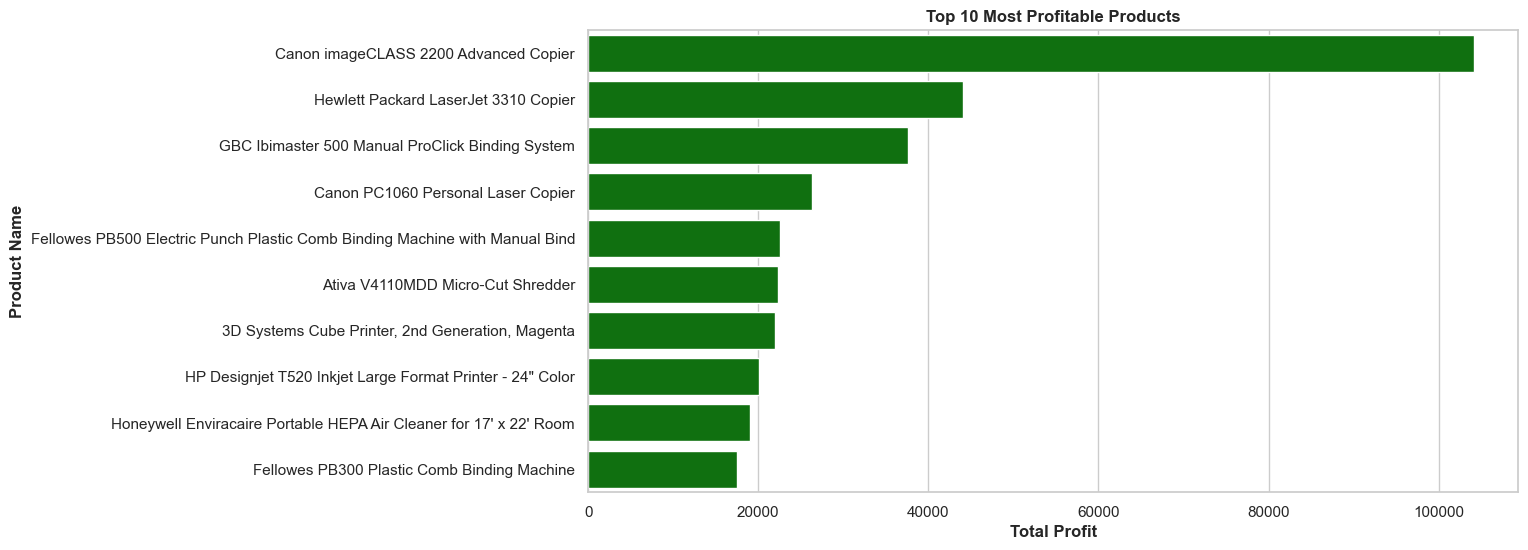

In [60]:
# Top 10 most profitable products
top_profit_products = (df.groupby('Product Name')['Total Profit'].sum().sort_values(ascending = False).head(10))
sns.set_style('whitegrid')
sns.barplot(x=top_profit_products.values,
           y= top_profit_products.index,color='green')
plt.title('Top 10 Most Profitable Products',fontweight='bold')
plt.xlabel('Total Profit',fontweight = 'bold')
plt.ylabel('Product Name',fontweight = 'bold')
plt.show()

<Axes: ylabel='Product Name'>

Text(0.5, 1.0, 'Top 10 Loss-making Products')

Text(0.5, 0, 'Total Profit')

Text(0, 0.5, 'Product Name')

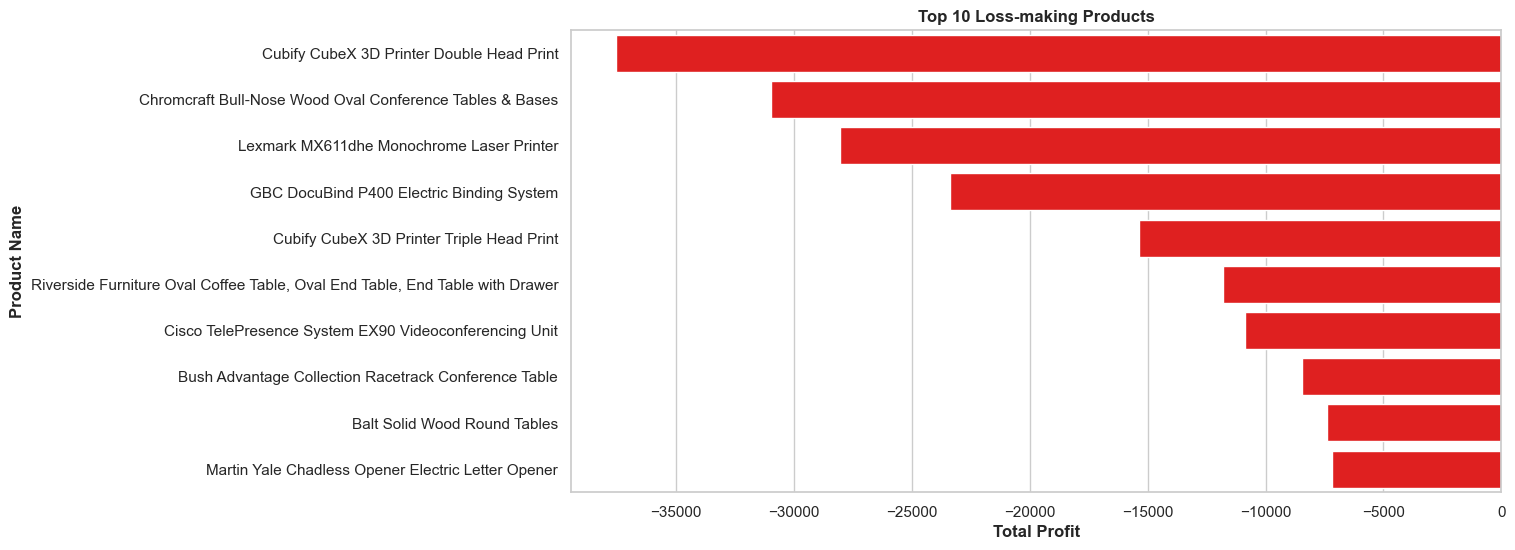

In [61]:
# most loss making product
top_loss_products = (df.groupby('Product Name')['Total Profit'].sum().sort_values(ascending = True).head(10))
 
sns.set_style('whitegrid')
sns.barplot(x=top_loss_products.values,
           y= top_loss_products.index,color='red')
plt.title('Top 10 Loss-making Products',fontweight='bold')
plt.xlabel('Total Profit',fontweight = 'bold')
plt.ylabel('Product Name',fontweight = 'bold')
plt.show()

<Figure size 1000x600 with 0 Axes>

<Axes: xlabel='Total Sales', ylabel='Total Profit'>

Text(0.5, 1.0, 'Sales vs Profit Correlation')

Text(0.5, 0, 'Total Sales')

Text(0, 0.5, 'Total Profit')

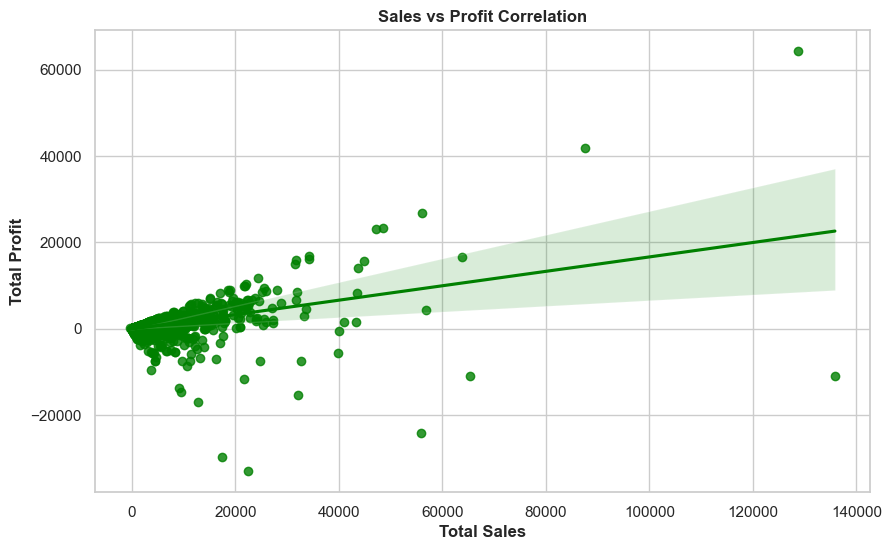

In [62]:
# Sales vs. Profit Correlation
plt.figure(figsize=(10,6))

sns.regplot(
    x='Total Sales', color='green',
    y='Total Profit',
    data=df
)

plt.title('Sales vs Profit Correlation',fontweight = 'bold')
plt.xlabel('Total Sales',fontweight = 'bold')
plt.ylabel('Total Profit',fontweight = 'bold')
plt.show()

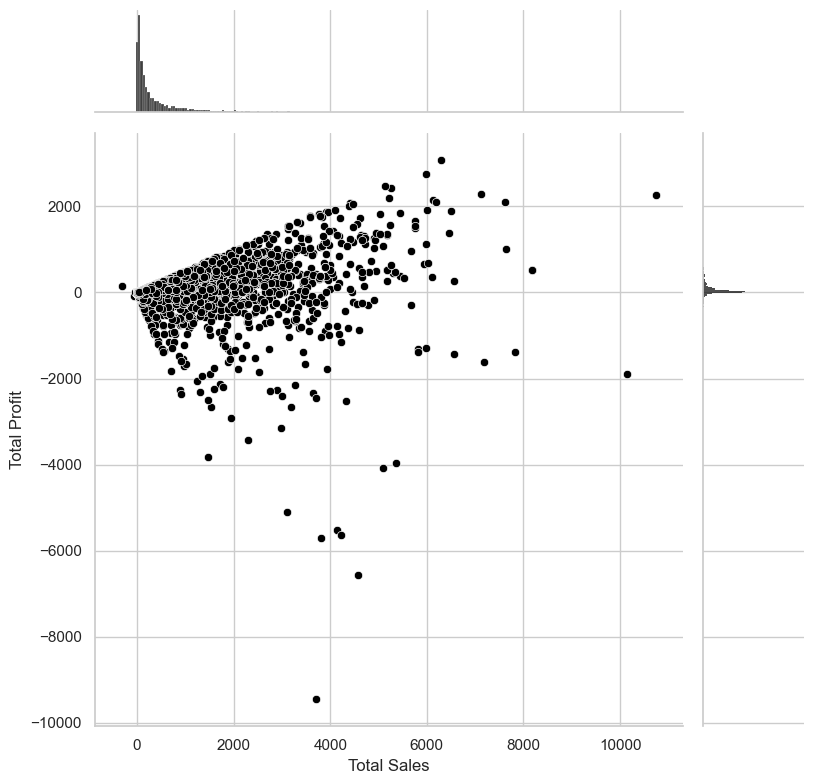

In [63]:
# Joint Distribution of Sales and Profit
sns.jointplot(
    x='Total Sales',
    y='Total Profit',color='black',
    data=df_cleaned,
    kind='scatter',
    height=8
)

plt.show()

In [64]:
df_cleaned.shape

(9329, 34)

### 2. Customer Segmentation and Analysis:
#### ● 1. Customer Sales Quintile vs. Customer Profit Quintile: Create a heatmap or cross-tabulation to explore the relationship between customers' sales and profit quintiles. This will help identify which segments of customers are most valuable.
#### ● 2. Understand how different product categories perform across customer segments: Create a pivot table to analyze the total Sales and total Profit by Category and Segment. Sort the pivot table to highlight the most profitable and least profitable combinations of Category and Segment

<Figure size 800x600 with 0 Axes>

<Axes: xlabel='Customer Profit Quintile', ylabel='Customer Sales Quintile'>

Text(0.5, 1.0, 'Customer Sales Quintile vs Profit Quintile')

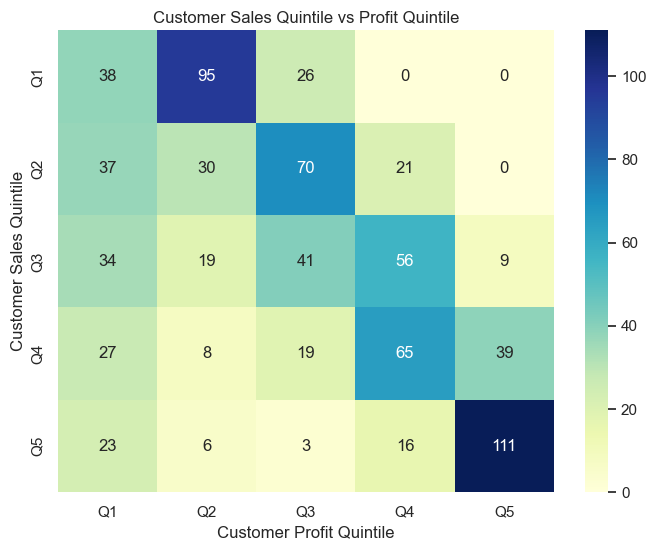

In [66]:
# Customer Sales Quintile vs. Customer Profit Quintile
plt.figure(figsize=(8,6))

sns.heatmap(
    cross_grid,
    annot=True,
    fmt='d',
    cmap='YlGnBu'
)

plt.title('Customer Sales Quintile vs Profit Quintile')

plt.show()

In [67]:
pivot_category_segment = pd.pivot_table(df, values=['Total Sales', 'Total Profit'],index='Category',columns='Segment',aggfunc='sum')
pivot_category_segment

Total Profit                             Total Sales  \
Segment             Consumer    Corporate  Home Office      Consumer   
Category                                                               
Furniture         43925.5388   39847.2854   25818.3942  2.054328e+06   
Office Supplies  281887.2648  202390.8643  124996.2840  1.803054e+06   
Technology       342860.3438  227239.0808  141533.0465  1.961866e+06   

                                            
Segment             Corporate  Home Office  
Category                                    
Furniture        1.150449e+06  654438.1015  
Office Supplies  1.152998e+06  591731.1800  
Technology       1.212598e+06  906437.7170

In [68]:
pivot_category_segment = pivot_category_segment.sort_values(('Total Profit', 'Consumer'),ascending = False)

In [69]:
pivot_category_segment

Total Profit                             Total Sales  \
Segment             Consumer    Corporate  Home Office      Consumer   
Category                                                               
Technology       342860.3438  227239.0808  141533.0465  1.961866e+06   
Office Supplies  281887.2648  202390.8643  124996.2840  1.803054e+06   
Furniture         43925.5388   39847.2854   25818.3942  2.054328e+06   

                                            
Segment             Corporate  Home Office  
Category                                    
Technology       1.212598e+06  906437.7170  
Office Supplies  1.152998e+06  591731.1800  
Furniture        1.150449e+06  654438.1015

<Axes: xlabel='Category'>

Text(0.5, 1.0, 'Profit by Category and Segment')

Text(0, 0.5, 'Total Profit')

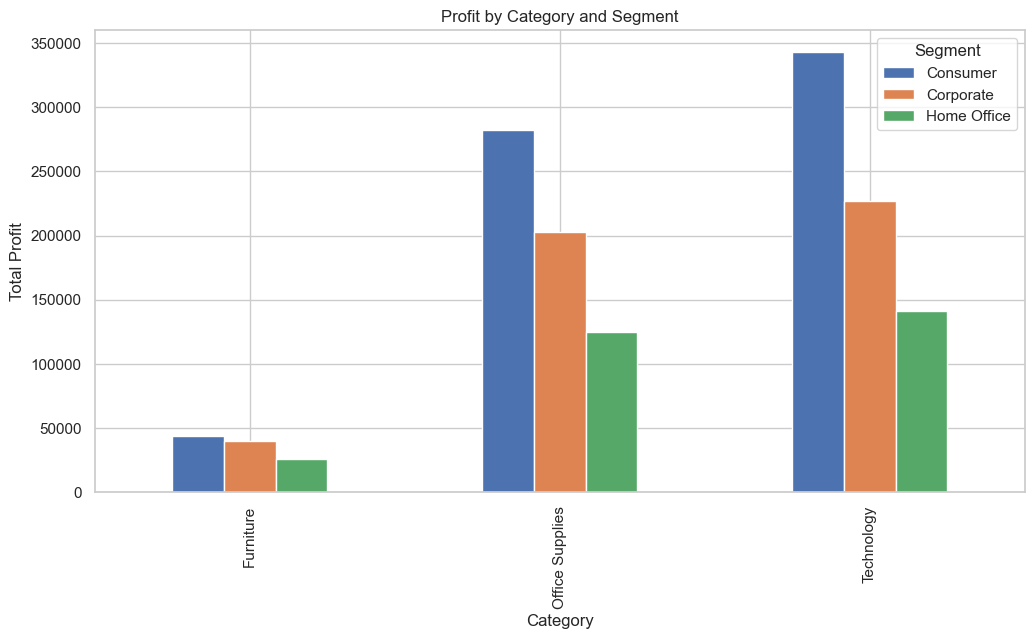

In [70]:
pivot_profit = pd.pivot_table(
    df,
    values='Total Profit',
    index='Category',
    columns='Segment',
    aggfunc='sum'
)

pivot_profit.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Profit by Category and Segment')

plt.ylabel('Total Profit')

plt.show()

### 3. Shipping and Delivery Analysis:
#### ● 1. Distribution of Shipping Urgency: Visualize the distribution of orders by Shipping Urgency using a pie chart or bar chart.
#### ● 2. Days to Ship vs. Profit: Use a violin plot to explore the distribution of Profit across different Days to Ship categories. This will help analyze whether faster shipping correlates with higher or lower profitability.
#### ● 3. Shipping Mode and Profitability: Create a grouped bar chart to compare the profitability of different shipping modes (e.g., Standard Class, First Class).
#### ● 4. Using pivot table, determine which shipping modes are most preferred across different regions and analyze the impact on total sales and profit. Create a pivot table that shows the count of Order IDs, total Sales, and total Profit for each Region and Ship Mode. Identify and print your insights

<Figure size 800x800 with 0 Axes>

([<matplotlib.patches.Wedge at 0x14a62a210>,
 [Text(-0.451375310714773, 1.0031252807486921, 'Standard'),
  Text(-0.22803777519612817, -1.0761035141117234, ''),
  Text(0.7751854078594841, -0.7804406341559399, 'Urgent'),
  Text(1.086449065136274, -0.1721291052219725, 'Immediate')],
 [Text(-0.2462047149353307, 0.547159244044741, '63.46%'),
  Text(-0.1243842410160699, -0.5869655531518491, '16.43%'),
  Text(0.42282840428699126, -0.4256948913577853, '15.10%'),
  Text(0.5926085809834221, -0.09388860284834863, '5.00%')])

Text(0.5, 1.0, 'Distribution of order shipping Urgency')

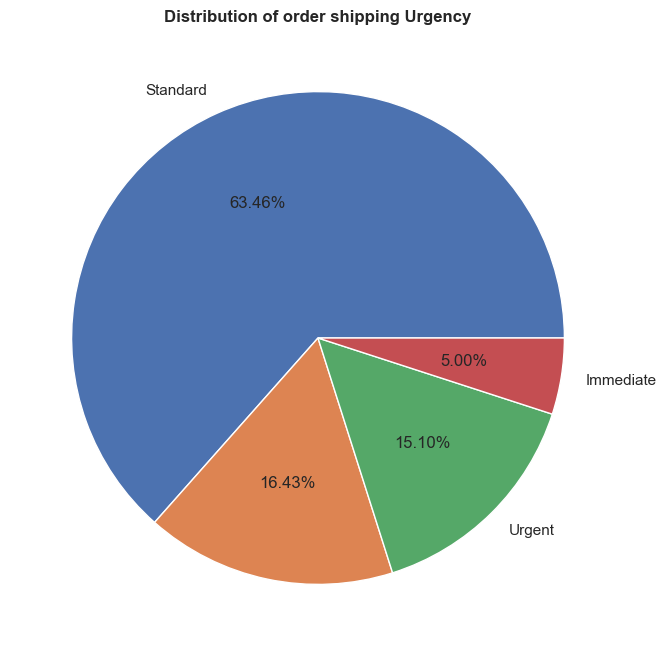

In [72]:
# Distribution of Shipping Urgency
shipping_count = df['Shipping Urgency'].value_counts()
plt.figure(figsize=(8,8))
plt.pie(shipping_count,
        labels=shipping_count.index,
        autopct='%1.2f%%',
        wedgeprops={'width':1.})
plt.title('Distribution of order shipping Urgency', fontweight='bold')
plt.show()

<Axes: xlabel='Shipping Urgency', ylabel='Total Profit'>

Text(0.5, 1.0, 'Profit Distribution by shipping urgency')

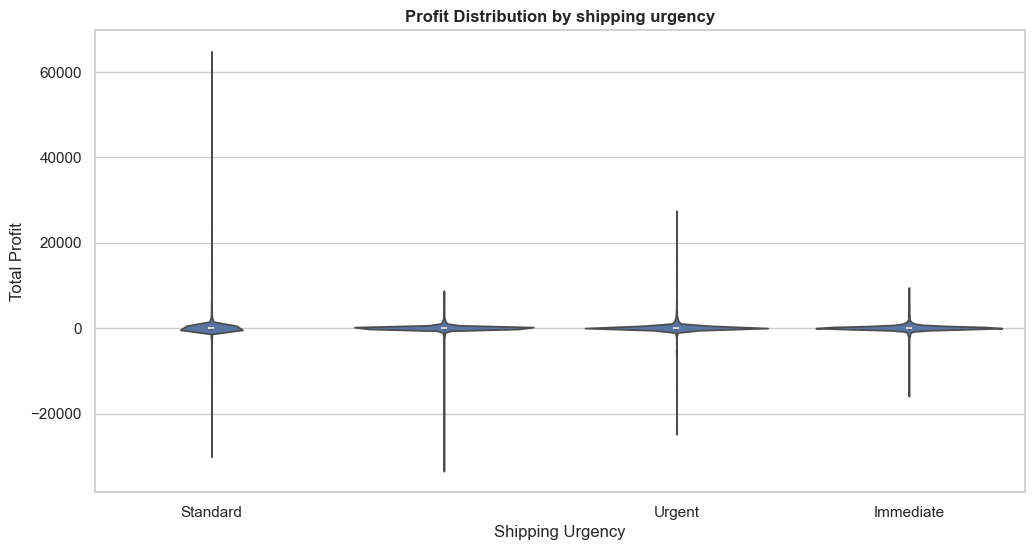

In [73]:
# Days to Ship vs. Profit
sns.violinplot(x='Shipping Urgency',
              y='Total Profit',
data=df)
plt.title('Profit Distribution by shipping urgency', fontweight='bold')

<Axes: xlabel='Ship Mode'>

Text(0.5, 1.0, 'Profitability by Shipping Mode')

Text(0, 0.5, 'Total Profit')

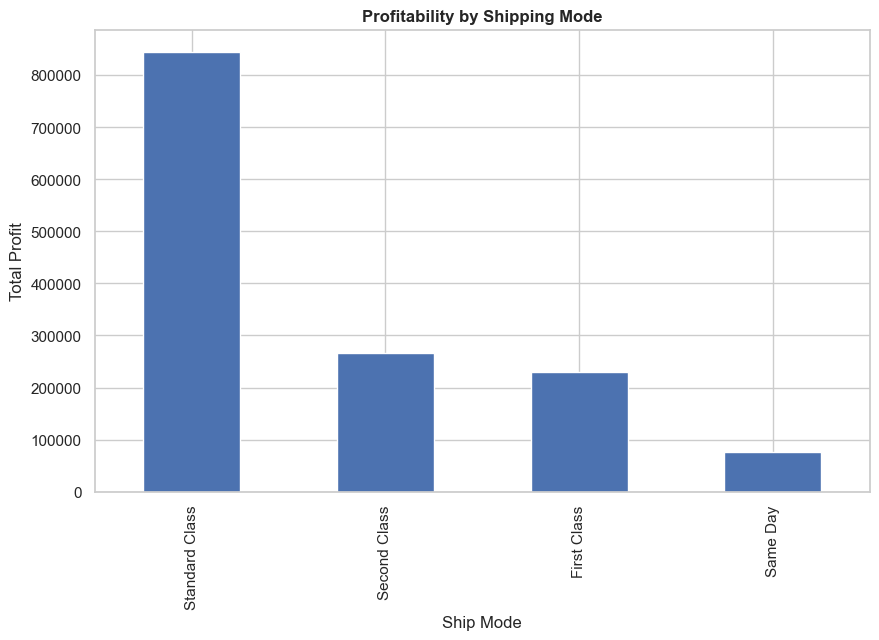

In [74]:
# Shipping Mode and Profitability
shipping_profit= (df.groupby('Ship Mode')['Total Profit'].sum().sort_values(ascending=False))
shipping_profit.plot(kind='bar',figsize=(10,6))
plt.title('Profitability by Shipping Mode', fontweight='bold')
plt.ylabel('Total Profit')
plt.show()

In [75]:
shipping_region_pivot = pd.pivot_table(df, values=['Order ID', 'Total Sales', 'Total Profit'],
        index='Region',columns='Ship Mode',
        aggfunc={
            'Order ID': 'count',
            'Total Sales': 'sum',
            'Total Profit': 'sum'})
print(shipping_region_pivot)

             Order ID                                      Total Profit  \
Ship Mode First Class Same Day Second Class Standard Class  First Class   
Region                                                                    
Central           300      120          465           1437    5105.0401   
East              490      155          530           1659   92341.4555   
South             235       83          329            968   32215.6732   
West              515      185          622           1882  100166.0172   

                                                   Total Sales              \
Ship Mode    Same Day Second Class Standard Class  First Class    Same Day   
Region                                                                       
Central     8152.7979   47510.6009    158759.7335  272293.7314   88764.084   
East       35834.1418   50031.2048    258247.3497  545641.5830  194830.102   
South      -5275.9360   58959.1303    141866.3493  224015.9200   97285.791   
West  

### 4. Regional Sales and Profitability:
#### ● 1. Sales and Profit by Region: Use a map or bar chart to visualize total sales and profit by region or state. This will highlight which regions are the most profitable.
#### ● 2. State-wise Profitability: Create a pivot table to summarize the profitability of each state. Highlight the top and bottom states based on profitability.
#### ● 3. Correlation between State and Profit: Use a correlation plot to identify any patterns correlationships between the states and the profitability of orders. (Hint: Convert thecategorical 'State' column into numerical values using label encoding using "from sklearn.preprocessing import LabelEncoder")

<Axes: xlabel='Region'>

Text(0.5, 1.0, 'Sales and Profit by region')

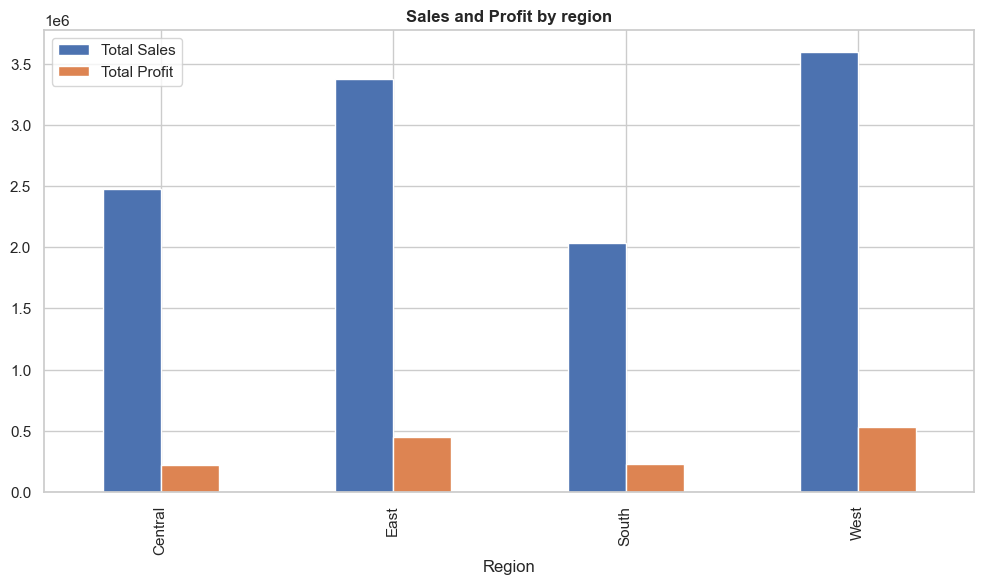

In [150]:
# Sales and Profit by Region
region_summary = (df.groupby('Region')[['Total Sales', 'Total Profit']].sum())
region_summary.plot(kind='bar',figsize=(12,6))
plt.title('Sales and Profit by region',fontweight='bold')
plt.show()

In [152]:
# State-wise Profitability
state_profit = pd.pivot_table(df,values='Total Profit',index='State',aggfunc='sum')
state_profit = state_profit.sort_values(by='Total Profit', ascending=False)
print(state_profit)

                      Total Profit
State                             
California             379017.4735
New York               367020.4694
Washington             165801.3331
Michigan               146948.9346
Virginia                99084.5224
Indiana                 89085.4907
Georgia                 78563.7237
Kentucky                58908.6024
Minnesota               49259.1076
Rhode Island            45699.7771
Wisconsin               45573.4348
Delaware                40159.5822
Missouri                34060.0975
Alabama                 33831.9763
Maryland                31203.2698
Massachusetts           30798.5538
Oklahoma                24138.7990
New Jersey              24088.2992
New Jursey              23738.3902
Mississippi             17170.5584
Arkansas                16164.0583
Connecticut             16002.9504
Nevada                  14218.5871
Vermont                 13761.5635
Utah                    11839.7455
Nebraska                11314.5656
Louisiana           

In [156]:
print(state_profit.head(5))
print(state_profit.tail(5))

            Total Profit
State                   
California   379017.4735
New York     367020.4694
Washington   165801.3331
Michigan     146948.9346
Virginia      99084.5224
                Total Profit
State                       
North Carolina   -45731.0934
Illinois         -57702.5335
Ohio             -80553.5750
Pennsylvania     -82838.4763
Texas           -135047.1019


In [169]:
# Correlation between State and Profi
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['State Encoded'] = le.fit_transform(df['State'])
df['State Encoded']


0        3
1        3
2       31
3       31
4        3
        ..
9992    12
9993    41
9994     8
9995     8
9996     3
Name: State Encoded, Length: 9997, dtype: int64

,State Encoded,Total Profit
State Encoded,1.000000,-0.020746
Total Profit,-0.020746,1.000000


<Axes: >

Text(0.5, 1.0, 'correlation between State and Profit')

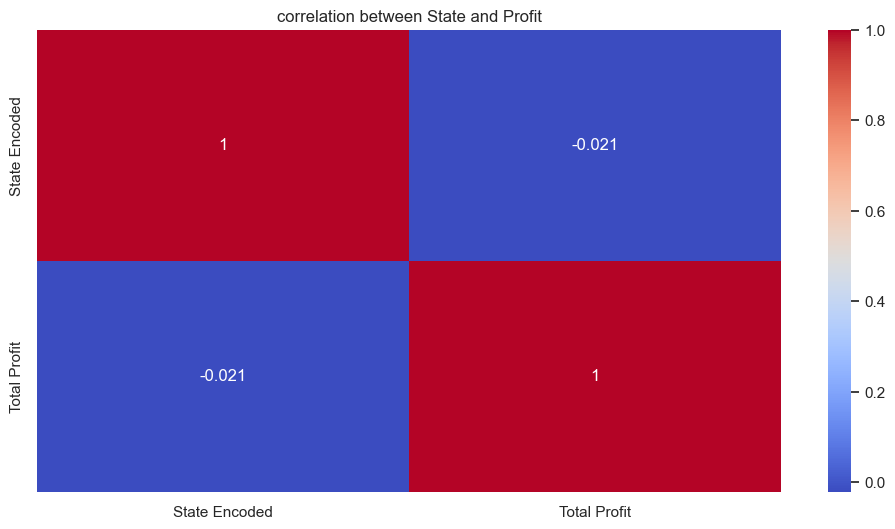

In [177]:
correlation = df[['State Encoded', 'Total Profit']].corr()
correlation
sns.heatmap(correlation,annot=True,cmap='coolwarm')
plt.title('Correlation between State and Profit')
plt.show()

### 5. Discount and Pricing Analysis:
#### ● 1. Impact of Discounts on Profitability: Use a scatter plot with a trend line to analyze how different levels of discount affect profitability.
#### ● 2. Original Price vs. Discounted Price: Create a line plot to compare the original price and the discounted price across various product categories or sub-categories.

<Figure size 1000x600 with 0 Axes>

<Axes: xlabel='Discount', ylabel='Total Profit'>

Text(0.5, 1.0, 'Impact of Discount on Profitability')

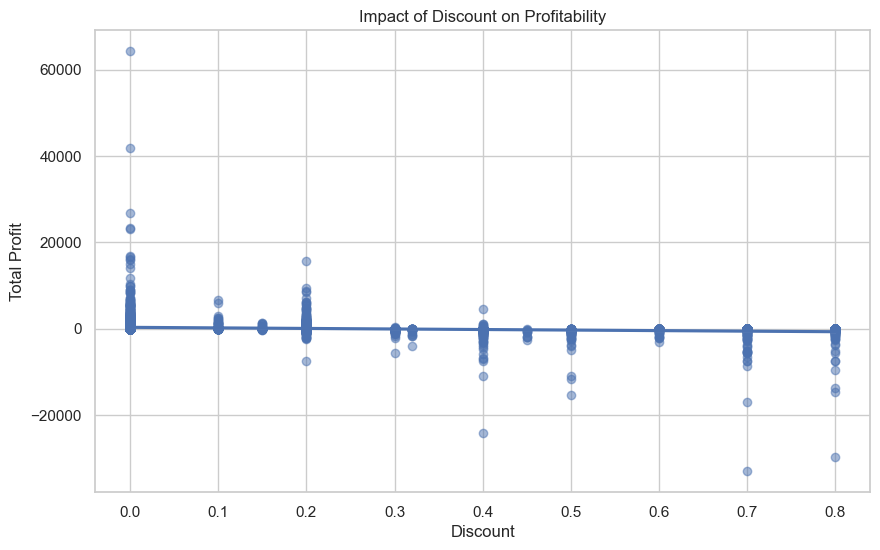

In [184]:
plt.figure(figsize=(10,6))

sns.regplot(
    x='Discount',
    y='Total Profit',
    data=df,
    scatter_kws={'alpha':0.5}
)

plt.title('Impact of Discount on Profitability')

plt.show()

<Axes: xlabel='Category'>

Text(0.5, 1.0, 'Original Price vs Discount Price')

Text(0, 0.5, 'Average Price')

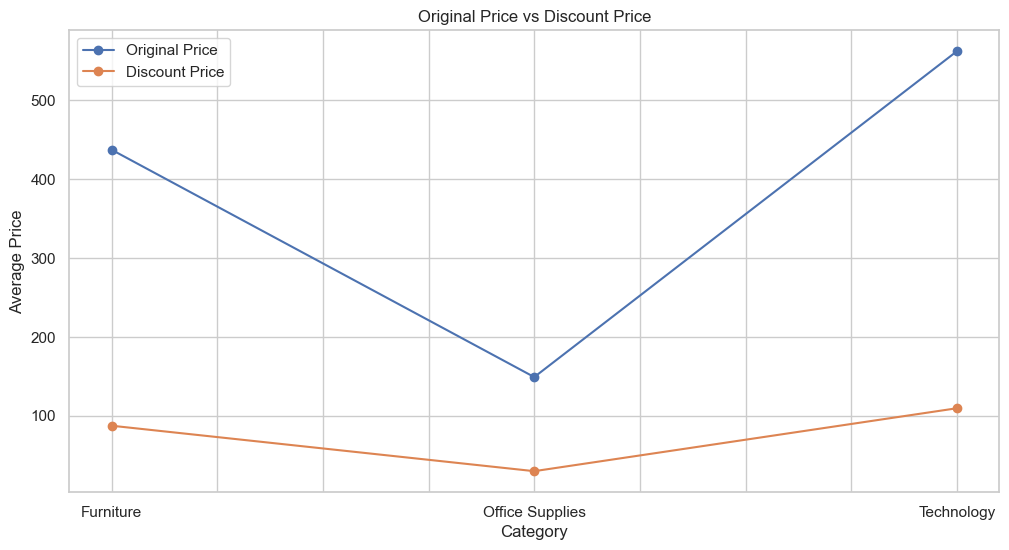

In [186]:
category_price = (
    df.groupby('Category')[
        ['Original Price', 'Discount Price']
    ]
    .mean()
)

category_price.plot(
    kind='line',
    marker='o',
    figsize=(12,6)
)

plt.title('Original Price vs Discount Price')

plt.ylabel('Average Price')

plt.show()

### 6. Temporal Analysis:
#### ● 1. Sales and Profit Trends Over Time: Use a time series plot to analyze how sales and profit have trended over the years or months. This will help in identifying any seasonal patterns.
#### ● 2. Order Frequency by Month: Use a bar chart or line plot to show the number of orders placed each month. Highlight any months with unusually high or low order frequencies.
#### ● 3. Yearly Growth in Sales and Profit: Use a year-over-year growth chart to compare the sales and profit growth over different years.

In [188]:
df['YearMonth'] = df['Order Date'].dt.to_period('M')

In [190]:
monthly_trend = (
    df.groupby('YearMonth')[
        ['Total Sales', 'Total Profit']
    ]
    .sum()
)

monthly_trend.index = monthly_trend.index.astype(str)

<Axes: xlabel='YearMonth'>

Text(0.5, 1.0, 'Sales and Profit Trends Over Time')

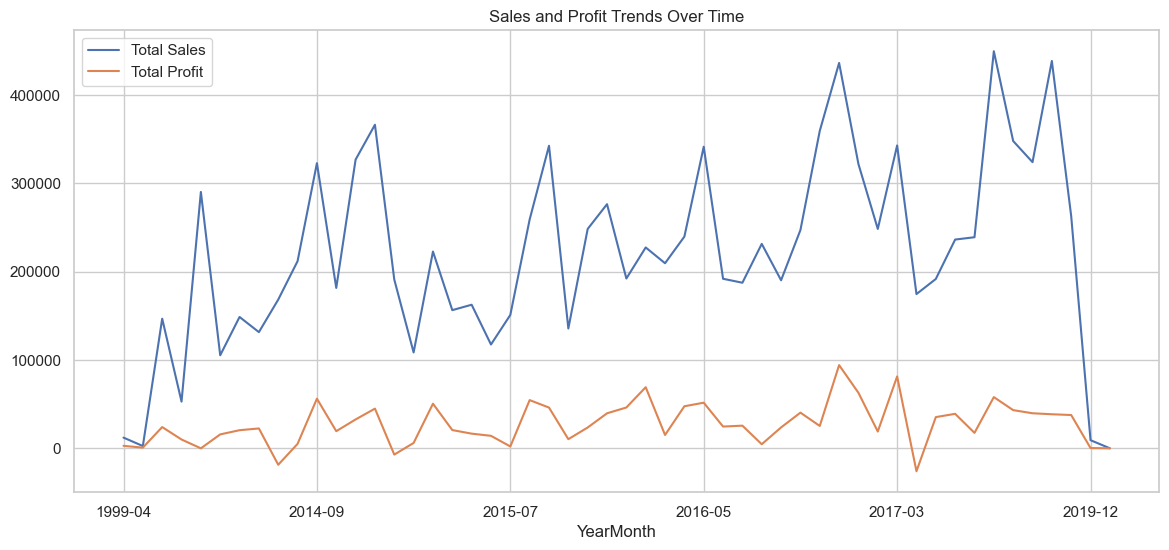

In [192]:
monthly_trend.plot(
    figsize=(14,6)
)

plt.title('Sales and Profit Trends Over Time')

plt.show()

<Axes: xlabel='Order Date'>

Text(0.5, 1.0, 'Order Frequency by Month')

Text(0.5, 0, 'Month')

Text(0, 0.5, 'Number of Orders')

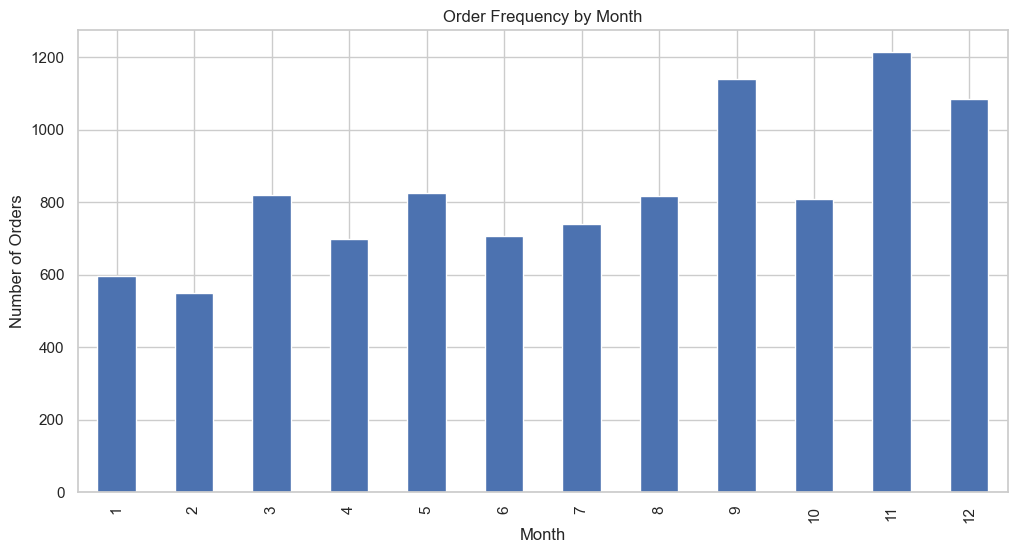

In [194]:
monthly_orders = (
    df.groupby(df['Order Date'].dt.month)['Order ID']
    .count()
)

monthly_orders.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Order Frequency by Month')

plt.xlabel('Month')

plt.ylabel('Number of Orders')

plt.show()

In [196]:
df['Year'] = df['Order Date'].dt.year

In [198]:
yearly_summary = (
    df.groupby('Year')[
        ['Total Sales', 'Total Profit']
    ]
    .sum()
)

<Axes: xlabel='Year'>

Text(0.5, 1.0, 'Yearly Sales and Profit Growth')

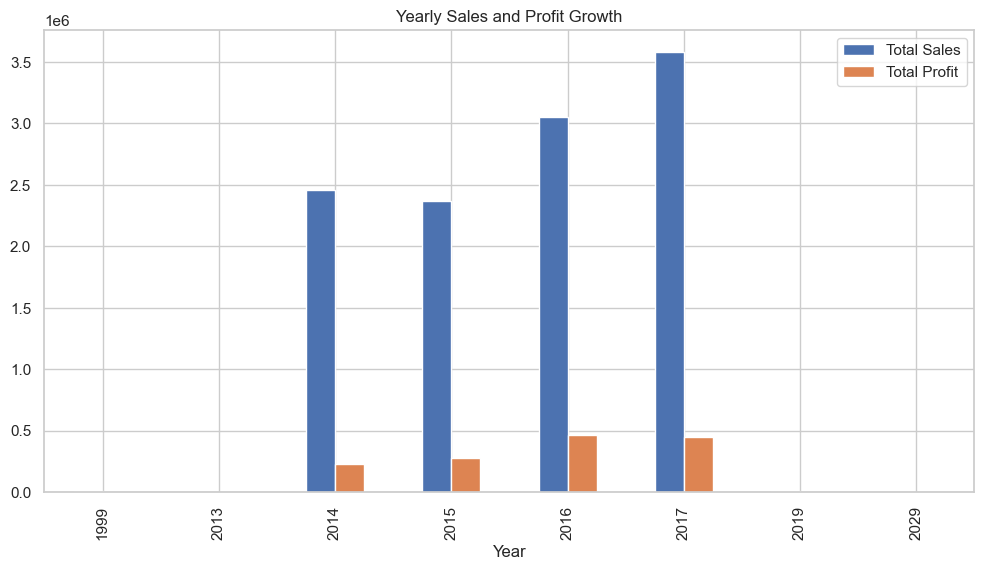

In [200]:
yearly_summary.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Yearly Sales and Profit Growth')

plt.show()